In [51]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns

df = pd.read_csv('online food delivery dataset.csv')

df_clean = df.drop(columns=['latitude','longitude','Pin code'])

df_clean

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,Output,Feedback,Unnamed: 13
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,Yes,Positive,Yes
...,...,...,...,...,...,...,...,...,...,...,...
383,23,Female,Single,Student,No Income,Post Graduate,2,Regular,Yes,Positive,Yes
384,23,Female,Single,Student,No Income,Post Graduate,4,Frequent,Yes,Positive,Yes
385,22,Female,Single,Student,No Income,Post Graduate,5,Frequent,Yes,Positive,Yes
386,23,Male,Single,Student,Below Rs.10000,Post Graduate,2,Regular,Yes,Positive,Yes


In [52]:
df_Feedback_pivot = pd.pivot_table(df_clean, index='Occupation',
             columns='Feedback', 
             aggfunc='count', 
             values= 'Age',
             fill_value=0 )

df_Feedback_pivot             

Feedback,Negative,Positive
Occupation,,
Employee,33,85
House wife,1,8
Self Employeed,16,38
Student,21,186


In [53]:
df_Feedback_pivot['Total'] = df_Feedback_pivot.sum(axis=1)
df_Feedback_pivot = df_Feedback_pivot.sort_values(by='Positive')
df_Feedback_pivot = df_Feedback_pivot.drop(columns='Total')

df_Feedback_pivot 

Feedback,Negative,Positive
Occupation,,
House wife,1,8
Self Employeed,16,38
Employee,33,85
Student,21,186


In [54]:
df_Feedback_percentage = df_Feedback_pivot.div(
    df_Feedback_pivot.sum(axis=1), axis=0
) *100

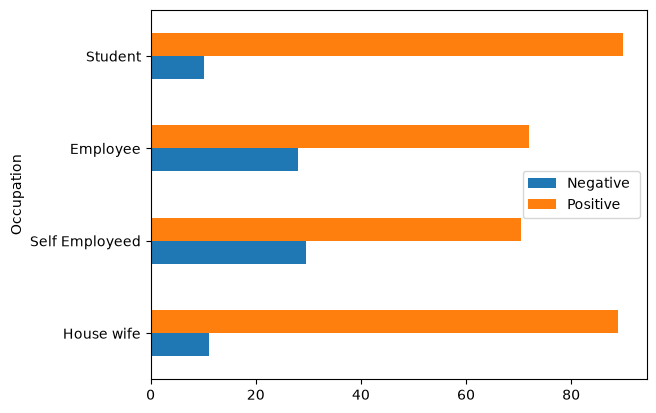

In [55]:
df_Feedback_plot = df_Feedback_percentage.plot(kind='barh')

plt.legend()
plt.show()
